In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
color_pal = sns.color_palette()

plt.style.use('fivethirtyeight')

In [184]:
power=pd.read_excel("PGCB_date_power_demand.xlsx")
weather=pd.read_excel("weather_data.xlsx",skiprows=3,header=0)               #reading the data
economic=pd.read_csv("economic_full_1 (1)22.csv")

In [185]:
power=power[['datetime', 'generation_mw', 'demand_mw']].copy()              #removing unnecessary columns

In [186]:
power=power.loc[~power.duplicated(subset=["datetime"])].reset_index(drop=True).copy()        #removing duplicates if any
weather=weather.loc[~weather.duplicated(subset=["time"])].reset_index(drop=True).copy()

In [187]:
power['datetime']=pd.to_datetime(power['datetime'])
weather['time']=pd.to_datetime(weather['time'])              #converting to datetime format

In [188]:
weather = weather.rename(columns={"time": "datetime"})

power_demand = pd.merge(power, weather, on="datetime", how="inner")      #merging the dataframes on datetime

In [189]:
df=power_demand[['datetime', 'demand_mw',
       'temperature_2m (°C)']].copy()         

In [190]:
df=df.loc[~df.duplicated(subset=["datetime"])].reset_index(drop=True).copy()   #removing duplicates if any

In [191]:
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

df = df.set_index("datetime")
df2 = df.resample("h").mean().ffill()
                                                                    #resampling to hourly frequency and forward filling missing values

df2.reset_index(inplace=True)

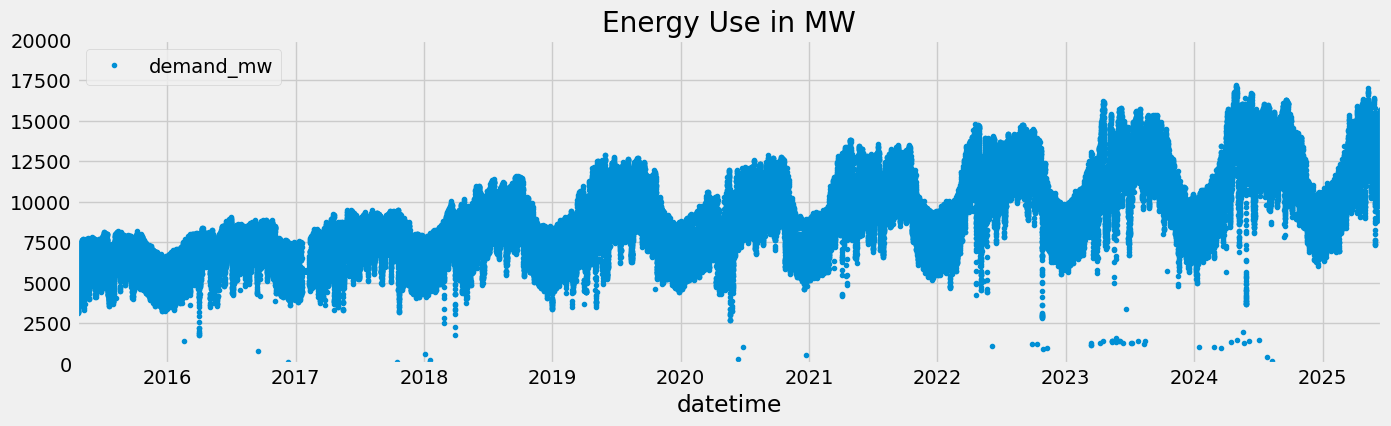

In [192]:
df2.plot(
    x="datetime",
    y="demand_mw",
    style='.',
    figsize=(15, 4),
    title='Energy Use in MW'
)
plt.ylim(0, 20000)

plt.show()

In [193]:



upper_limit = 20000
lower_limit = 3000


df2.loc[df2['demand_mw'] > upper_limit, 'demand_mw'] = np.nan
df2.loc[df2['demand_mw'] < lower_limit, 'demand_mw'] = np.nan             #removing outliers based on domain knowledge
df2['demand_mw'] = df2['demand_mw'].fillna(df2['demand_mw'].shift(24))



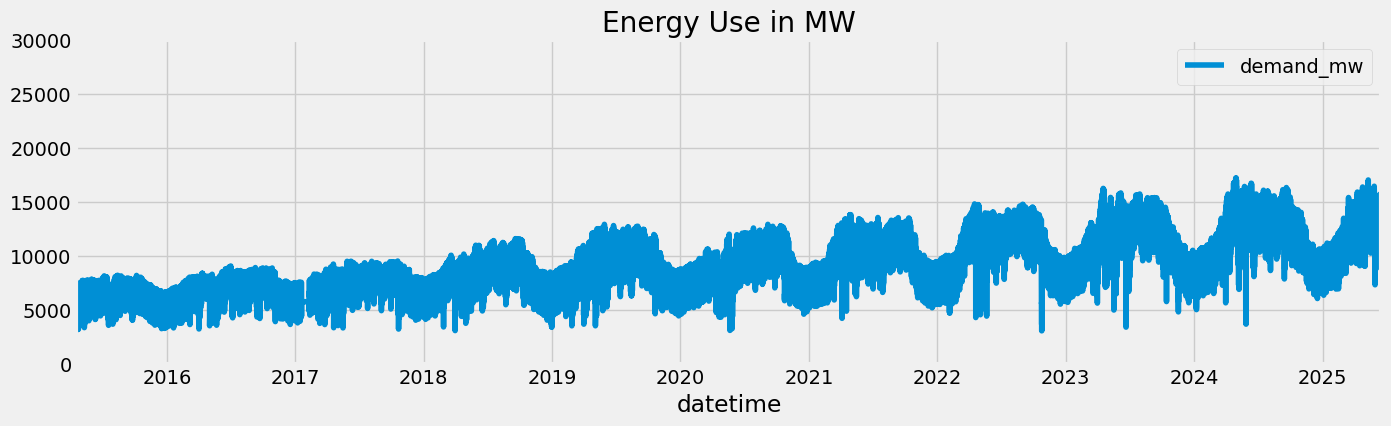

In [194]:
df2.plot(
    x="datetime",
    y="demand_mw",
   # style='.',
    figsize=(15, 4),
    title='Energy Use in MW'
)
plt.ylim(0, 30000)
plt.show()

In [195]:
df2.head()

,datetime,demand_mw,temperature_2m (°C)
0,2015-04-19 00:00:00,4821.0,25.7
1,2015-04-19 01:00:00,3612.0,25.3
2,2015-04-19 02:00:00,3727.0,24.9
3,2015-04-19 03:00:00,3632.0,25.0
4,2015-04-19 04:00:00,3641.0,25.2


In [196]:
df2.describe()

,datetime,demand_mw,temperature_2m (°C)
count,89101,89101.000000,89101.000000
mean,2020-05-18 06:00:00,8752.125419,25.540754
min,2015-04-19 00:00:00,3033.000000,8.400000
25%,2017-11-02 03:00:00,6739.000000,22.700000
50%,2020-05-18 06:00:00,8357.000000,26.500000
75%,2022-12-02 09:00:00,10564.000000,28.900000
max,2025-06-17 12:00:00,17200.000000,40.800000
std,NaN,2605.578225,5.007573


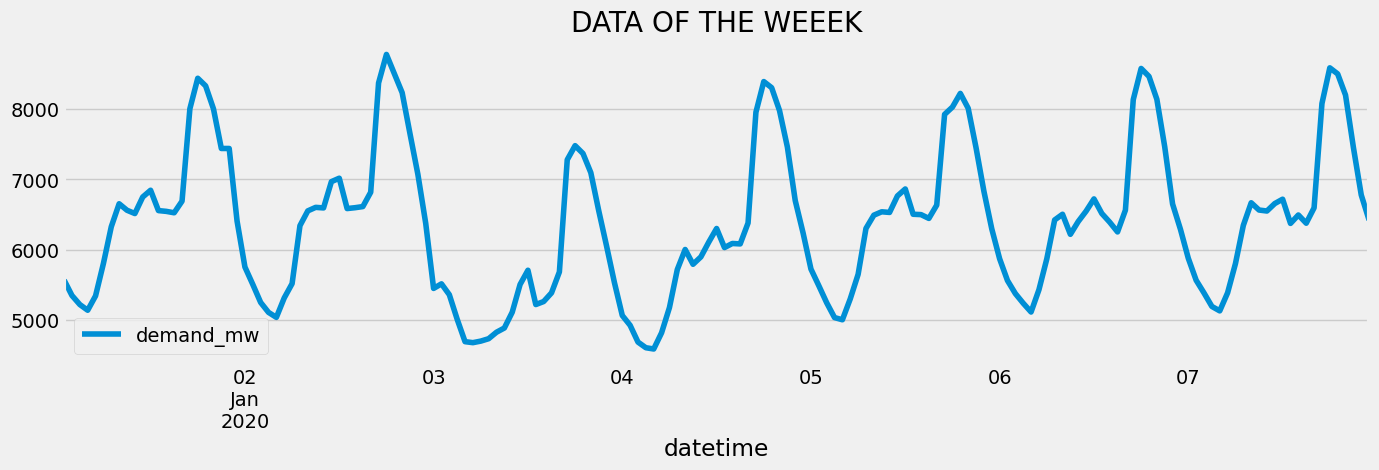

In [197]:
df2.loc[(df2['datetime'] > '01-01-2020') & (df2['datetime'] < '01-08-2020')].plot(
    y="demand_mw",
    x="datetime",

    figsize=(15, 4),
    title='DATA OF THE WEEEK'
)

plt.show()

In [198]:

def create_features(df2):
    """
    Create time series features based on time series index.
    """
    df2 = df2.copy()
    df2['hour'] = df2['datetime'].dt.hour
    df2['dayofweek'] =df2['datetime'].dt.dayofweek
    df2['month'] = df2['datetime'].dt.month        #feature engineering - creating new features based on datetime
    df2['year'] = df2['datetime'].dt.year
    df2['dayofyear'] = df2['datetime'].dt.dayofyear


    return df2

df2 = create_features(df2)

In [199]:
df2['hour_y'] = np.sin(2*np.pi*df2['hour']/24)
df2['hour_x'] = np.cos(2*np.pi*df2['hour']/24)

df2['dow_y'] = np.sin(2*np.pi*df2['dayofweek']/7)
df2['dow_x'] = np.cos(2*np.pi*df2['dayofweek']/7)
                                                        #creating cyclical features for hour of day and day of week 
                                                        # to capture the periodicity in the data
df2['month_y'] = np.sin(2*np.pi*df2['month']/12)
df2['month_x'] = np.cos(2*np.pi*df2['month']/12)



df2 = df2.drop(columns=['hour','dayofweek','month'])

In [200]:
df2 = df2.sort_values(by="datetime")


In [201]:
#improvising lag features for better performance of the model

df2["lag_1"] = df2["demand_mw"].shift(1)
df2["lag_2"] = df2["demand_mw"].shift(2)
df2["lag_24"] = df2["demand_mw"].shift(24)   


df2 = df2.dropna()


In [ ]:
df2.describe()                   #------final dataframe----

,datetime,demand_mw,temperature_2m (°C),year,dayofyear,hour_y,hour_x,dow_y,dow_x,month_y,month_x,lag_1,lag_2,lag_24
count,89077,89077.000000,89077.000000,89077.000000,89077.000000,8.907700e+04,8.907700e+04,89077.000000,89077.000000,8.907700e+04,8.907700e+04,89077.000000,89077.000000,89077.000000
mean,2020-05-18 18:00:00,8753.123208,25.540379,2019.880833,182.450329,8.527178e-05,-5.424173e-17,0.000114,0.000360,2.150950e-03,-1.510119e-02,8753.046690,8752.973686,8750.829990
min,2015-04-20 00:00:00,3033.000000,8.400000,2015.000000,1.000000,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,3033.000000,3033.000000,3033.000000
25%,2017-11-02 21:00:00,6741.000000,22.700000,2017.000000,93.000000,-7.071068e-01,-7.071068e-01,-0.781831,-0.900969,-5.000000e-01,-8.660254e-01,6741.000000,6741.000000,6739.000000
50%,2020-05-18 18:00:00,8357.000000,26.500000,2020.000000,180.000000,1.224647e-16,6.123234e-17,0.000000,-0.222521,1.224647e-16,-1.836970e-16,8357.000000,8357.000000,8356.000000
75%,2022-12-02 15:00:00,10565.000000,28.900000,2022.000000,273.000000,7.071068e-01,7.071068e-01,0.781831,0.623490,5.000000e-01,5.000000e-01,10565.000000,10564.000000,10561.000000
max,2025-06-17 12:00:00,17200.000000,40.800000,2025.000000,366.000000,1.000000e+00,1.000000e+00,0.974928,1.000000,1.000000e+00,1.000000e+00,17200.000000,17200.000000,17200.000000
std,NaN,2605.145554,5.008069,2.957685,104.786275,7.071068e-01,7.071147e-01,0.707027,0.707194,7.032828e-01,7.107544e-01,2605.116831,2605.093809,2604.666588


In [203]:
train = df2[df2["datetime"] < "2024-01-01"]
test = df2[(df2["datetime"] >= "2024-01-01") & (df2["datetime"] < "2025-01-01")]         #splitting the data into train
                                                                                          #and test based on datetime


In [204]:

from sklearn.metrics import mean_absolute_percentage_error

In [205]:
from lightgbm import LGBMRegressor

# Define model parameters          
params = {
    'objective': 'regression',
    'metric': 'mape',  # Optimization target
    'learning_rate': 0.05,
    'n_estimators': 500,
    'random_state': 42
}

X_train = train.drop(columns=["datetime","demand_mw"])
y_train = train["demand_mw"]

X_test = test.drop(columns=["datetime", "demand_mw"])
y_test = test["demand_mw"]
model = LGBMRegressor(**params)
model.fit(X_train, y_train)
# Predict on test data
y_pred = model.predict(X_test)

# Calculate MAPE (returns a decimal, multiply by 100 for percentage)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE: {mape * 100:.2f}%")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001691 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1352
[LightGBM] [Info] Number of data points in the train set: 76272, number of used features: 12
[LightGBM] [Info] Start training from score 8299.455213
MAPE: 1.89%


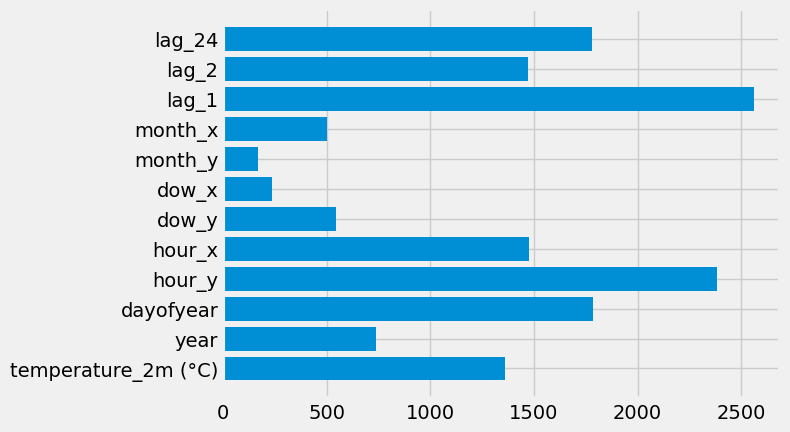

In [206]:
import matplotlib.pyplot as plt

importance  = model.feature_importances_                   #getting feature importance from the model to 
                                                            #understand which features are most influential in predicting the target variable

features = X_train.columns

plt.barh(features, importance)
plt.show()

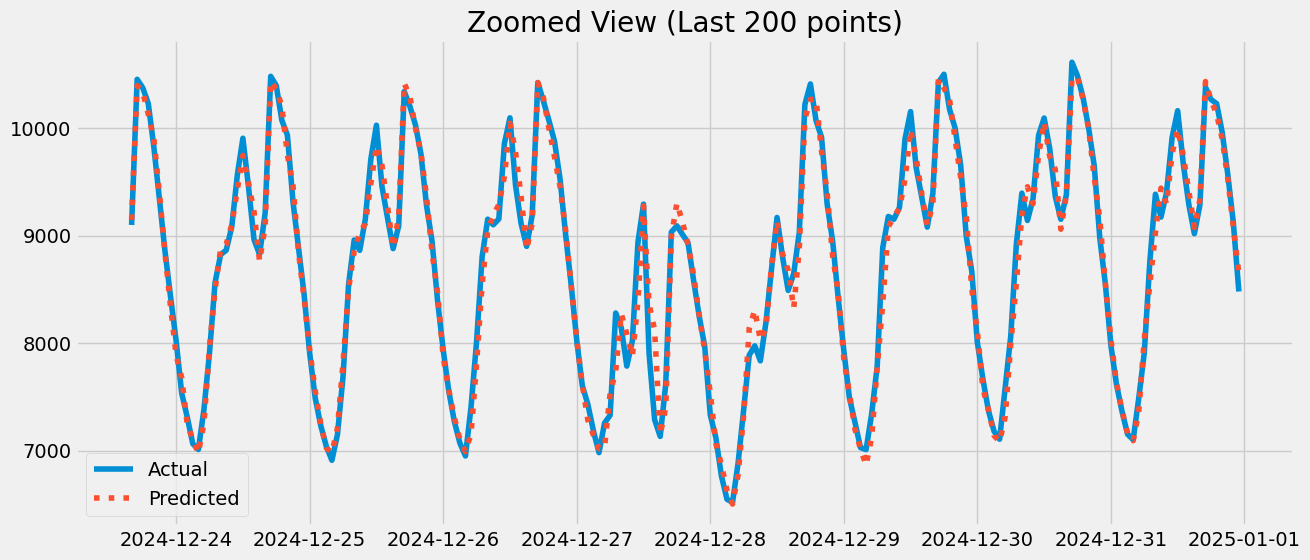

In [207]:
plt.figure(figsize=(14,6))

plt.plot(test["datetime"].tail(200), y_test.tail(200), label="Actual")
plt.plot(test["datetime"].tail(200), y_pred[-200:],linestyle=":", label="Predicted")
plt.style
plt.legend()                                                                           #plotting actual vs predicted data
plt.title("Zoomed View (Last 200 points)")

plt.show()